<a href="https://colab.research.google.com/github/ps-research/The-Language-of-AI-Liability/blob/main/Responsibility_Attribution_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Technique 2: Responsibility Attribution Analysis
## ACL ARR March 2026: The Language of AI Liability



In [ ]:
!python -m spacy download en_core_web_trf
!pip install spacy-curated-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.9/237.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 36.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ── Cell 1: Setup and load ──

import json
import re
import spacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from collections import defaultdict, Counter
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/ACL SRW TEXTS")
OUTPUT_DIR = BASE_DIR / "processed"
FIGURE_DIR = BASE_DIR / "figures"

with open(OUTPUT_DIR / "preprocessed_corpus.json", "r", encoding="utf-8") as f:
    results = json.load(f)

nlp = spacy.load("en_core_web_trf")
nlp.max_length = 700_000

LAW_ORDER = [
    "eu_ai_act", "china_genai", "south_korea",
    "ca_sb1047", "ca_sb53", "ca_sb942", "ca_ab2013",
    "co_sb205", "tx_traiga", "il_hb3773",
]

LAW_LABELS = {
    "eu_ai_act":   "EU AI Act",
    "china_genai":  "China GenAI Measures",
    "south_korea":  "South Korea AI Basic Act",
    "ca_sb1047":    "CA SB 1047 (vetoed)",
    "ca_sb53":      "CA SB 53",
    "ca_sb942":     "CA SB 942",
    "ca_ab2013":    "CA AB 2013",
    "co_sb205":     "CO SB 205",
    "tx_traiga":    "TX TRAIGA",
    "il_hb3773":    "IL HB 3773",
}

print(f"Loaded {len(results)} laws")

Loaded 10 laws


In [ ]:
# ── Cell 2: Voice classification ──

def classify_voice(doc):
    """Classify a parsed sentence as active, passive, or indeterminate
    based on dependency labels.

    Returns:
      'active'  — has nsubj (nominal subject, active)
      'passive' — has nsubjpass or has auxpass
      'indeterminate' — neither detected (e.g., fragments, imperatives)
    """
    has_nsubj = False
    has_passive = False

    for token in doc:
        if token.dep_ == "nsubj":
            has_nsubj = True
        if token.dep_ in ("nsubjpass", "nsubj:pass"):
            has_passive = True
        if token.dep_ == "auxpass" or token.dep_ == "aux:pass":
            has_passive = True

    if has_passive:
        return "passive"
    elif has_nsubj:
        return "active"
    else:
        return "indeterminate"


# Run voice classification on all obligation sentences
voice_results = {}

for law_id in LAW_ORDER:
    sents = results[law_id]["sentences"]
    obligation_sents = [s for s in sents if s["is_obligation"]]

    counts = {"active": 0, "passive": 0, "indeterminate": 0}
    classified_sents = []

    for s in obligation_sents:
        doc = nlp(s["text"])
        voice = classify_voice(doc)
        counts[voice] += 1
        classified_sents.append({
            "sent_id": s["sent_id"],
            "text": s["text"],
            "voice": voice,
        })

    voice_results[law_id] = {
        "counts": counts,
        "total_obligation": len(obligation_sents),
        "sentences": classified_sents,
    }

    active_pct = counts["active"] / len(obligation_sents) * 100 if obligation_sents else 0
    passive_pct = counts["passive"] / len(obligation_sents) * 100 if obligation_sents else 0
    print(f"{law_id:<22} active: {counts['active']:>4} ({active_pct:5.1f}%)  "
          f"passive: {counts['passive']:>4} ({passive_pct:5.1f}%)  "
          f"indet: {counts['indeterminate']:>3}")

eu_ai_act              active:  376 ( 53.0%)  passive:  326 ( 45.9%)  indet:   8
china_genai            active:   12 ( 75.0%)  passive:    4 ( 25.0%)  indet:   0
south_korea            active:   59 ( 57.8%)  passive:   43 ( 42.2%)  indet:   0
ca_sb1047              active:   27 ( 48.2%)  passive:   29 ( 51.8%)  indet:   0
ca_sb53                active:   21 ( 38.9%)  passive:   33 ( 61.1%)  indet:   0
ca_sb942               active:    7 ( 53.8%)  passive:    6 ( 46.2%)  indet:   0
ca_ab2013              active:    1 ( 33.3%)  passive:    2 ( 66.7%)  indet:   0
co_sb205               active:   14 ( 56.0%)  passive:   11 ( 44.0%)  indet:   0
tx_traiga              active:   26 ( 60.5%)  passive:   17 ( 39.5%)  indet:   0
il_hb3773              active:    9 ( 56.2%)  passive:    7 ( 43.8%)  indet:   0


In [ ]:
# ── Cell 3: Actor dictionary construction ──

# Stage 1: Seed list of common regulatory actor terms
SEED_ACTORS = {
    # Specific regulated entities
    "developer": "regulated_entity",
    "developers": "regulated_entity",
    "provider": "regulated_entity",
    "providers": "regulated_entity",
    "deployer": "regulated_entity",
    "deployers": "regulated_entity",
    "operator": "regulated_entity",
    "operators": "regulated_entity",
    "distributor": "regulated_entity",
    "distributors": "regulated_entity",
    "importer": "regulated_entity",
    "importers": "regulated_entity",
    "manufacturer": "regulated_entity",
    "manufacturers": "regulated_entity",
    "employer": "regulated_entity",
    "employers": "regulated_entity",
    "covered entity": "regulated_entity",
    "service provider": "regulated_entity",
    "service providers": "regulated_entity",

    # Government / institutional actors
    "commission": "government",
    "department": "government",
    "agency": "government",
    "board": "government",
    "council": "government",
    "authority": "government",
    "office": "government",
    "attorney general": "government",
    "secretary": "government",
    "minister": "government",
    "government": "government",
    "state": "government",

    # Generic actors
    "person": "generic",
    "persons": "generic",
    "entity": "generic",
    "entities": "generic",
    "individual": "generic",
    "individuals": "generic",
    "user": "generic",
    "users": "generic",
    "member state": "generic",
    "member states": "generic",
    "notified body": "generic",
    "notified bodies": "generic",
}

# Stage 2: Extract defined terms from each law's definitional sentences
# and supplement the seed list with law-specific actor terms

DEFINITION_PATTERN = re.compile(
    r'["\u201c]([^"\u201d]+)["\u201d]\s+means\b'
    r'|\b(\w[\w\s]*?)\s+means\b'
    r'|["\u201c]([^"\u201d]+)["\u201d]\s+has\s+the\s+(?:same\s+)?meaning',
    re.IGNORECASE
)

# Actor-like terms from definitions (words that suggest an actor role)
ACTOR_INDICATORS = re.compile(
    r'\b(?:person|entity|individual|organization|body|office|agency|'
    r'department|board|council|authority|provider|developer|deployer|'
    r'operator|employer|distributor|importer|manufacturer|user|'
    r'company|firm|institution|service)\b',
    re.IGNORECASE
)

law_specific_actors = {}

for law_id in LAW_ORDER:
    sents = results[law_id]["sentences"]
    definitional = [s for s in sents if s["is_definitional"]]
    extracted = {}

    for s in definitional:
        matches = DEFINITION_PATTERN.findall(s["text"])
        for groups in matches:
            term = next((g.strip().lower() for g in groups if g.strip()), None)
            if term and len(term) < 60:
                # Check if the definition text describes an actor
                # Look at the full sentence for actor indicators
                if ACTOR_INDICATORS.search(s["text"]):
                    extracted[term] = "regulated_entity"

    law_specific_actors[law_id] = extracted
    if extracted:
        print(f"{law_id}: extracted {len(extracted)} actor terms: "
              f"{list(extracted.keys())[:5]}")

print(f"\nSeed actors: {len(SEED_ACTORS)} terms")

eu_ai_act: extracted 1 actor terms: ['providing']
south_korea: extracted 9 actor terms: ['high-impact ai', 'core operations and management of', 'generative ai', 'ai industry', 'ai business operator']
ca_sb1047: extracted 12 actor terms: ['advanced persistent threat', 'artificial intelligence', 'artificial intelligence safety incident', 'computing cluster', 'covered model']
ca_sb53: extracted 9 actor terms: ['affiliate', 'catastrophic risk', 'critical safety incident', 'deploy', 'frontier developer']
ca_sb942: extracted 5 actor terms: ['covered provider', 'manifest', 'personal provenance data', 'provenance data', 'system provenance data']
ca_ab2013: extracted 4 actor terms: ['artificial intelligence', 'developer', 'substantial modification', 'security and integrity']
co_sb205: extracted 11 actor terms: ['algorithmic discrimination', 'artificial intelligence system', 'consequential decision', 'consumer', 'deployer']
tx_traiga: extracted 15 actor terms: ['artificial intelligence system', 

In [ ]:
# ── Cell 4: Subject extraction and actor classification ──

def extract_subject(doc):
    """Extract the subject noun phrase from a parsed sentence.
    Returns the text of the subject's subtree (the full noun phrase)
    and the head noun."""
    for token in doc:
        if token.dep_ == "nsubj":
            # Get the full noun phrase via the subtree
            subtree_span = doc[token.left_edge.i : token.right_edge.i + 1]
            return {
                "head": token.text.lower(),
                "full_np": subtree_span.text,
                "head_lemma": token.lemma_.lower(),
            }
    return None


def classify_actor(subject_info, law_id):
    """Classify an extracted subject against the actor dictionary.
    Checks law-specific actors first, then seed list.

    Returns (actor_label, actor_category) or (None, 'unclassified').
    """
    if subject_info is None:
        return None, "unclassified"

    head = subject_info["head_lemma"]
    full_np = subject_info["full_np"].lower()

    # Check law-specific actors first
    for term, cat in law_specific_actors.get(law_id, {}).items():
        if term in full_np:
            return term, cat

    # Check seed list — try full NP first, then head noun
    for term, cat in SEED_ACTORS.items():
        if term in full_np:
            return term, cat

    # Check head lemma against seed keys
    for term, cat in SEED_ACTORS.items():
        if head == term or head == term.rstrip("s"):
            return term, cat

    return subject_info["full_np"][:40], "unclassified"


# Run actor extraction on all active-voice obligation sentences
actor_results = {}

for law_id in LAW_ORDER:
    v_sents = voice_results[law_id]["sentences"]
    active_sents = [s for s in v_sents if s["voice"] == "active"]

    actor_counts = Counter()
    category_counts = Counter()
    extractions = []
    classified_count = 0

    for s in active_sents:
        doc = nlp(s["text"])
        subject = extract_subject(doc)
        actor_label, actor_cat = classify_actor(subject, law_id)

        if actor_cat != "unclassified":
            classified_count += 1

        actor_counts[actor_label] += 1
        category_counts[actor_cat] += 1
        extractions.append({
            "sent_id": s["sent_id"],
            "voice": "active",
            "subject": subject,
            "actor_label": actor_label,
            "actor_category": actor_cat,
        })

    total_active = len(active_sents)
    coverage = classified_count / total_active if total_active > 0 else 0

    # Herfindahl index over classified actors only
    classified_actors = {k: v for k, v in actor_counts.items()
                         if classify_actor({"head_lemma": "", "full_np": k or ""},
                                           law_id)[1] != "unclassified"
                         or k in SEED_ACTORS}

    # Recompute properly: use the extractions directly
    classified_labels = [e["actor_label"] for e in extractions
                         if e["actor_category"] != "unclassified"]
    classified_counter = Counter(classified_labels)
    total_classified = sum(classified_counter.values())

    if total_classified > 0:
        shares = np.array(list(classified_counter.values())) / total_classified
        hhi = float(np.sum(shares ** 2))
    else:
        hhi = 0.0

    actor_results[law_id] = {
        "total_active": total_active,
        "classified_count": classified_count,
        "coverage": coverage,
        "hhi": hhi,
        "actor_counts": dict(actor_counts.most_common()),
        "category_counts": dict(category_counts),
        "extractions": extractions,
    }

    top3 = actor_counts.most_common(3)
    top3_str = ", ".join(f"{k}: {v}" for k, v in top3)
    print(f"{law_id:<22} active: {total_active:>3}  "
          f"classified: {classified_count:>3} ({coverage:.0%})  "
          f"HHI: {hhi:.3f}  top: [{top3_str}]")

eu_ai_act              active: 376  classified: 232 (62%)  HHI: 0.141  top: [commission: 54, authority: 43, provider: 36]
china_genai            active:  12  classified:   9 (75%)  HHI: 1.000  top: [provider: 9, Those providing generative AI services w: 1, generative AI services provided from out: 1]
south_korea            active:  59  classified:  41 (69%)  HHI: 0.311  top: [minister: 16, government: 16, The Committee: 4]
ca_sb1047              active:  27  classified:  20 (74%)  HHI: 0.280  top: [developer: 9, covered model: 4, agency: 3]
ca_sb53                active:  21  classified:  14 (67%)  HHI: 0.255  top: [frontier developer: 6, department: 3, This reporting: 1]
ca_sb942               active:   7  classified:   5 (71%)  HHI: 0.680  top: [covered provider: 4, The disclosure: 1, attorney general: 1]
ca_ab2013              active:   1  classified:   1 (100%)  HHI: 1.000  top: [developer: 1]
co_sb205               active:  14  classified:  12 (86%)  HHI: 0.375  top: [deployer: 6,

In [ ]:
# ── Cell 5: Build display data for figures ──

# Voice data
voice_df = pd.DataFrame({
    "Active": {lid: voice_results[lid]["counts"]["active"] /
               voice_results[lid]["total_obligation"] * 100
               if voice_results[lid]["total_obligation"] > 0 else 0
               for lid in LAW_ORDER},
    "Passive": {lid: voice_results[lid]["counts"]["passive"] /
                voice_results[lid]["total_obligation"] * 100
                if voice_results[lid]["total_obligation"] > 0 else 0
                for lid in LAW_ORDER},
    "Indeterminate": {lid: voice_results[lid]["counts"]["indeterminate"] /
                      voice_results[lid]["total_obligation"] * 100
                      if voice_results[lid]["total_obligation"] > 0 else 0
                      for lid in LAW_ORDER},
}).loc[LAW_ORDER]

# Actor concentration — build a matrix of top actor shares per law
# Identify the globally most frequent actor labels across all laws
global_actor_freq = Counter()
for law_id in LAW_ORDER:
    for e in actor_results[law_id]["extractions"]:
        if e["actor_category"] != "unclassified":
            global_actor_freq[e["actor_label"]] += 1

# Take top N actors globally + an "Other classified" bucket
TOP_N_ACTORS = 8
top_actors = [a for a, _ in global_actor_freq.most_common(TOP_N_ACTORS)]

# Build actor share matrix
actor_share_data = {}
for law_id in LAW_ORDER:
    classified_labels = [e["actor_label"] for e in actor_results[law_id]["extractions"]
                         if e["actor_category"] != "unclassified"]
    total = len(classified_labels)
    if total == 0:
        actor_share_data[law_id] = {a: 0 for a in top_actors}
        actor_share_data[law_id]["Other"] = 0
        continue

    counts = Counter(classified_labels)
    shares = {}
    accounted = 0
    for actor in top_actors:
        s = counts.get(actor, 0) / total * 100
        shares[actor] = s
        accounted += counts.get(actor, 0)
    shares["Other"] = (total - accounted) / total * 100
    actor_share_data[law_id] = shares

actor_share_df = pd.DataFrame(actor_share_data).T.loc[LAW_ORDER]

# Clean up column names for display
actor_display_names = {a: a.replace("_", " ").title() if a != "Other" else "Other"
                       for a in actor_share_df.columns}
actor_share_df = actor_share_df.rename(columns=actor_display_names)

# Drop columns that are all zeros
actor_share_df = actor_share_df.loc[:, (actor_share_df > 0).any(axis=0)]

print("\nVoice distribution (%):")
print(voice_df.round(1).to_string())
print(f"\nActor share matrix (% of classified obligations):")
print(actor_share_df.round(1).to_string())
print(f"\nHHI values:")
for lid in LAW_ORDER:
    print(f"  {LAW_LABELS[lid]:<30} {actor_results[lid]['hhi']:.3f}  "
          f"(coverage: {actor_results[lid]['coverage']:.0%})")


Voice distribution (%):
             Active  Passive  Indeterminate
eu_ai_act      53.0     45.9            1.1
china_genai    75.0     25.0            0.0
south_korea    57.8     42.2            0.0
ca_sb1047      48.2     51.8            0.0
ca_sb53        38.9     61.1            0.0
ca_sb942       53.8     46.2            0.0
ca_ab2013      33.3     66.7            0.0
co_sb205       56.0     44.0            0.0
tx_traiga      60.5     39.5            0.0
il_hb3773      56.2     43.8            0.0

Actor share matrix (% of classified obligations):
             Commission  Provider  Authority  Office  Deployer  State  Minister  Government  Other
eu_ai_act          23.3      15.5       18.5     9.5       7.3    9.1       0.0         0.0   16.8
china_genai         0.0     100.0        0.0     0.0       0.0    0.0       0.0         0.0    0.0
south_korea         0.0       0.0        0.0     0.0       0.0    2.4      39.0        39.0   19.5
ca_sb1047           0.0       0.0        0.0

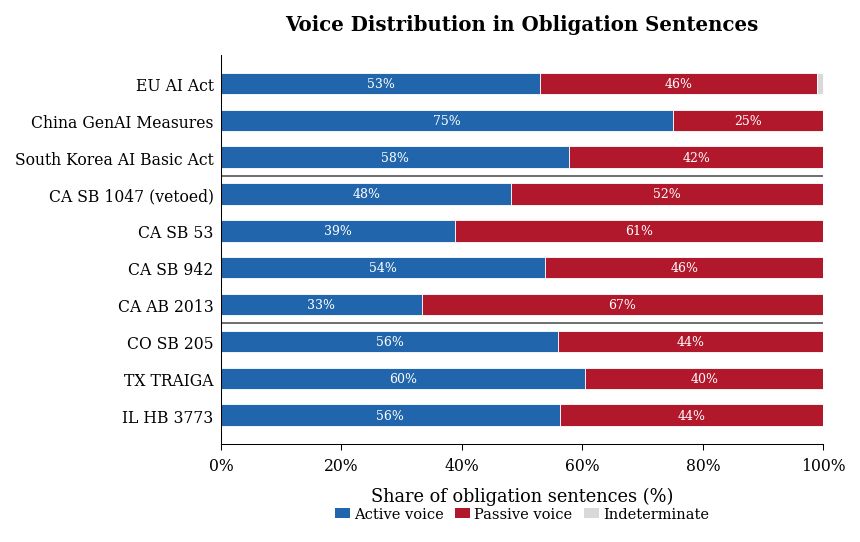

Saved: /content/drive/MyDrive/ACL SRW TEXTS/figures/fig3a_voice_distribution.pdf


In [ ]:
# ── Cell 6: Figure 3a — Active vs. Passive Voice ──

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "stix",
})

fig_a, ax_a = plt.subplots(figsize=(5.5, 3.5), dpi=150)

ylabels = [LAW_LABELS[lid] for lid in LAW_ORDER]
y_pos = np.arange(len(LAW_ORDER))

color_active = "#2166ac"
color_passive = "#b2182b"
color_indet = "#d9d9d9"

# Stacked horizontal bars
active_vals = voice_df["Active"].values
passive_vals = voice_df["Passive"].values
indet_vals = voice_df["Indeterminate"].values

ax_a.barh(y_pos, active_vals, height=0.58, color=color_active,
          edgecolor="white", linewidth=0.4, label="Active voice")
ax_a.barh(y_pos, passive_vals, left=active_vals, height=0.58,
          color=color_passive, edgecolor="white", linewidth=0.4,
          label="Passive voice")
ax_a.barh(y_pos, indet_vals, left=active_vals + passive_vals, height=0.58,
          color=color_indet, edgecolor="white", linewidth=0.4,
          label="Indeterminate")

# Annotate segments > 10%
for vals, lefts, color_text in [
    (active_vals, np.zeros(len(LAW_ORDER)), "white"),
    (passive_vals, active_vals, "white"),
    (indet_vals, active_vals + passive_vals, "#333333"),
]:
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v > 10:
            ax_a.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                     fontsize=6, color=color_text, fontweight="medium")

ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(ylabels, fontsize=7.5)
ax_a.set_xlim(0, 100)
ax_a.set_xlabel("Share of obligation sentences (%)", fontsize=8.5, labelpad=6)
ax_a.invert_yaxis()
ax_a.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax_a.xaxis.set_major_locator(mticker.MultipleLocator(20))
ax_a.tick_params(axis="x", labelsize=7.5, length=3, width=0.5)
ax_a.tick_params(axis="y", length=0)

for y_line in [2.5, 6.5]:
    ax_a.axhline(y=y_line, color="#555555", linewidth=0.8, linestyle="-")

ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)
ax_a.spines["left"].set_linewidth(0.5)
ax_a.spines["bottom"].set_linewidth(0.5)

# Legend
handles_a = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_active, edgecolor="none"),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_passive, edgecolor="none"),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_indet, edgecolor="none"),
]
ax_a.legend(handles_a, ["Active voice", "Passive voice", "Indeterminate"],
            loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3,
            fontsize=7, frameon=False, handlelength=1.0, handletextpad=0.3,
            columnspacing=0.8)

ax_a.set_title("Voice Distribution in Obligation Sentences",
               pad=12, fontweight="bold", fontsize=9.5)

fig_a.subplots_adjust(left=0.22, right=0.95, top=0.90, bottom=0.16)
fig_a.savefig(FIGURE_DIR / "fig3a_voice_distribution.pdf", dpi=1200,
              bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Saved: {FIGURE_DIR / 'fig3a_voice_distribution.pdf'}")

In [ ]:
# Patch: check which key exists and normalize
for law_id in LAW_ORDER:
    ar = actor_results[law_id]
    if "classified_real_actors" not in ar and "classified_count" in ar:
        ar["classified_real_actors"] = ar["classified_count"]
    elif "classified_real_actors" not in ar:
        # Recompute from extractions
        ar["classified_real_actors"] = sum(
            1 for e in ar["extractions"]
            if e["actor_category"] in ("regulated_entity", "government", "generic")
        )
print("Patched. Re-run the figure cell.")

Patched. Re-run the figure cell.


Voice distribution (%):
             Active  Passive  Indeterminate
eu_ai_act      53.0     45.9            1.1
china_genai    75.0     25.0            0.0
south_korea    57.8     42.2            0.0
ca_sb1047      48.2     51.8            0.0
ca_sb53        38.9     61.1            0.0
ca_sb942       53.8     46.2            0.0
ca_ab2013      33.3     66.7            0.0
co_sb205       56.0     44.0            0.0
tx_traiga      60.5     39.5            0.0
il_hb3773      56.2     43.8            0.0

Actor category distribution (% of active-voice obligation sentences):
             regulated_entity  government  generic  anaphoric  non_actor
eu_ai_act                15.7        39.4      6.6        0.0        0.0
china_genai              75.0         0.0      0.0        0.0        0.0
south_korea               8.5        57.6      3.4        0.0        0.0
ca_sb1047                59.3        14.8      0.0        0.0        0.0
ca_sb53                  38.1        28.6      0.0      

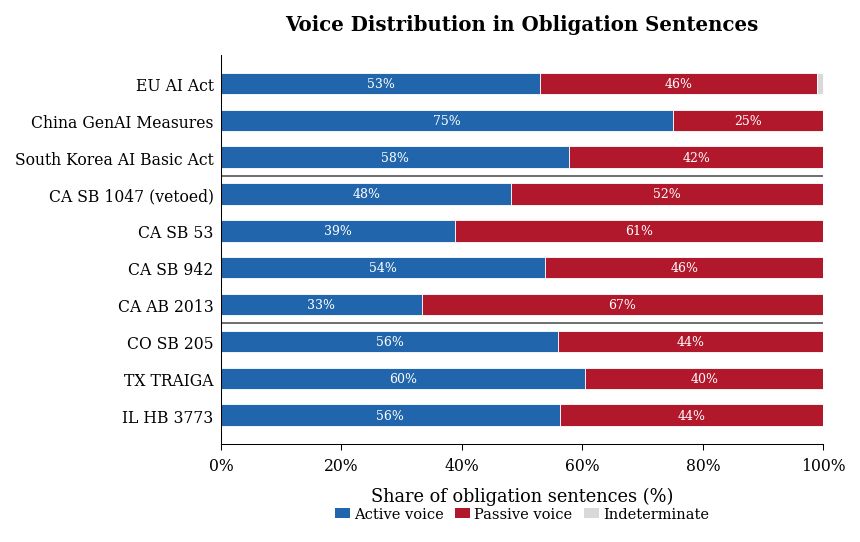

Saved: /content/drive/MyDrive/ACL SRW TEXTS/figures/fig3a_voice_distribution.pdf


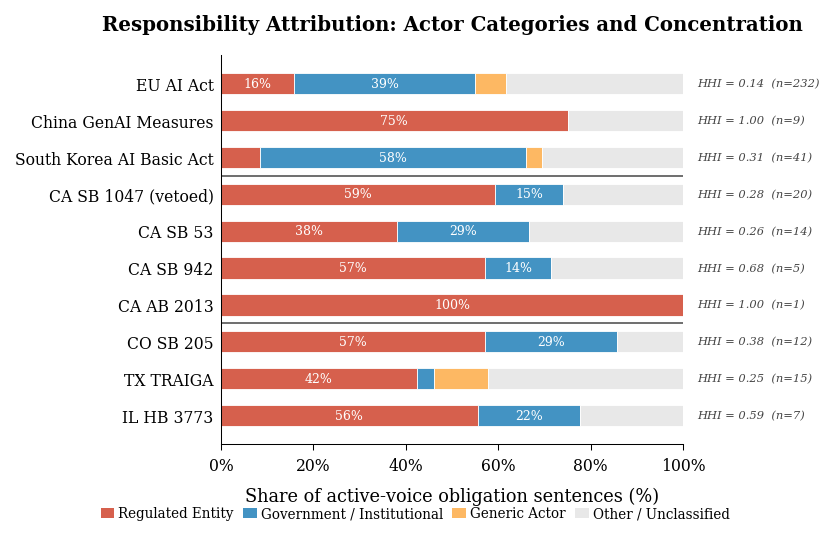

Saved: /content/drive/MyDrive/ACL SRW TEXTS/figures/fig3b_actor_concentration.pdf


In [ ]:
# ── Cell: Build display data ──

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "stix",
})

# Voice percentages
voice_df = pd.DataFrame({
    "Active": {lid: voice_results[lid]["counts"]["active"] /
               voice_results[lid]["total_obligation"] * 100
               if voice_results[lid]["total_obligation"] > 0 else 0
               for lid in LAW_ORDER},
    "Passive": {lid: voice_results[lid]["counts"]["passive"] /
                voice_results[lid]["total_obligation"] * 100
                if voice_results[lid]["total_obligation"] > 0 else 0
                for lid in LAW_ORDER},
    "Indeterminate": {lid: voice_results[lid]["counts"]["indeterminate"] /
                      voice_results[lid]["total_obligation"] * 100
                      if voice_results[lid]["total_obligation"] > 0 else 0
                      for lid in LAW_ORDER},
}).loc[LAW_ORDER]

# Actor category percentages (over active-voice sentences only)
DISPLAY_CATS = ["regulated_entity", "government", "generic", "anaphoric", "non_actor"]
CAT_DISPLAY_NAMES = {
    "regulated_entity": "Regulated Entity",
    "government": "Government / Institutional",
    "generic": "Generic Actor",
    "anaphoric": "Anaphoric Reference",
    "non_actor": "Non-Actor Subject",
}

cat_data = {}
for law_id in LAW_ORDER:
    cc = actor_results[law_id]["category_counts"]
    total_active = actor_results[law_id]["total_active"]
    if total_active == 0:
        cat_data[law_id] = {c: 0 for c in DISPLAY_CATS}
        continue
    cat_data[law_id] = {c: cc.get(c, 0) / total_active * 100 for c in DISPLAY_CATS}

cat_df = pd.DataFrame(cat_data).T.loc[LAW_ORDER]

print("Voice distribution (%):")
print(voice_df.round(1).to_string())
print(f"\nActor category distribution (% of active-voice obligation sentences):")
print(cat_df.round(1).to_string())
print(f"\nHHI values (computed over classified real actors only):")
for lid in LAW_ORDER:
    ar = actor_results[lid]
    print(f"  {LAW_LABELS[lid]:<30} HHI={ar['hhi']:.3f}  "
          f"coverage={ar['coverage']:.0%}  "
          f"({ar['classified_real_actors']}/{ar['total_active']} active)")


# ── Figure 3a: Voice Distribution ──

fig_a, ax_a = plt.subplots(figsize=(5.5, 3.5), dpi=150)

ylabels = [LAW_LABELS[lid] for lid in LAW_ORDER]
y_pos = np.arange(len(LAW_ORDER))

color_active = "#2166ac"
color_passive = "#b2182b"
color_indet = "#d9d9d9"

active_vals = voice_df["Active"].values
passive_vals = voice_df["Passive"].values
indet_vals = voice_df["Indeterminate"].values

ax_a.barh(y_pos, active_vals, height=0.58, color=color_active,
          edgecolor="white", linewidth=0.4)
ax_a.barh(y_pos, passive_vals, left=active_vals, height=0.58,
          color=color_passive, edgecolor="white", linewidth=0.4)
ax_a.barh(y_pos, indet_vals, left=active_vals + passive_vals, height=0.58,
          color=color_indet, edgecolor="white", linewidth=0.4)

for vals, lefts, color_text in [
    (active_vals, np.zeros(len(LAW_ORDER)), "white"),
    (passive_vals, active_vals, "white"),
    (indet_vals, active_vals + passive_vals, "#333333"),
]:
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v > 10:
            ax_a.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                     fontsize=6, color=color_text, fontweight="medium")

ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(ylabels, fontsize=7.5)
ax_a.set_xlim(0, 100)
ax_a.set_xlabel("Share of obligation sentences (%)", fontsize=8.5, labelpad=6)
ax_a.invert_yaxis()
ax_a.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax_a.xaxis.set_major_locator(mticker.MultipleLocator(20))
ax_a.tick_params(axis="x", labelsize=7.5, length=3, width=0.5)
ax_a.tick_params(axis="y", length=0)

for y_line in [2.5, 6.5]:
    ax_a.axhline(y=y_line, color="#555555", linewidth=0.8, linestyle="-")

ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)
ax_a.spines["left"].set_linewidth(0.5)
ax_a.spines["bottom"].set_linewidth(0.5)

# Legend — explicit handles, no edge color
handles_a = [
    plt.Rectangle((0, 0), 1, 1, facecolor=color_active, edgecolor="none"),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_passive, edgecolor="none"),
    plt.Rectangle((0, 0), 1, 1, facecolor=color_indet, edgecolor="none"),
]
ax_a.legend(handles_a, ["Active voice", "Passive voice", "Indeterminate"],
            loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3,
            fontsize=7, frameon=False, handlelength=1.0, handletextpad=0.3,
            columnspacing=0.8)

ax_a.set_title("Voice Distribution in Obligation Sentences",
               pad=12, fontweight="bold", fontsize=9.5)

fig_a.subplots_adjust(left=0.22, right=0.95, top=0.90, bottom=0.16)
fig_a.savefig(FIGURE_DIR / "fig3a_voice_distribution.pdf", dpi=1200,
              bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Saved: {FIGURE_DIR / 'fig3a_voice_distribution.pdf'}")


# ── Figure 3b: Actor Category Distribution + HHI ──

fig_b, ax_b = plt.subplots(figsize=(5.5, 3.5), dpi=150)

y_pos = np.arange(len(LAW_ORDER))
ylabels = [LAW_LABELS[lid] for lid in LAW_ORDER]

real_cats = ["regulated_entity", "government", "generic"]
real_colors = {
    "regulated_entity": "#d6604d",
    "government":       "#4393c3",
    "generic":          "#fdb863",
}
real_labels = {
    "regulated_entity": "Regulated Entity",
    "government":       "Government / Institutional",
    "generic":          "Generic Actor",
}

left = np.zeros(len(LAW_ORDER))
for cat in real_cats:
    vals = cat_df[cat].values
    ax_b.barh(y_pos, vals, left=left, height=0.58,
              color=real_colors[cat], edgecolor="white", linewidth=0.4)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 12:
            text_color = "white" if cat != "generic" else "#333333"
            ax_b.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                     fontsize=6, color=text_color, fontweight="medium")
    left += vals

# Remaining space as light gray
remaining = 100 - left
for i, r in enumerate(remaining):
    if r > 0:
        ax_b.barh(y_pos[i], r, left=left[i], height=0.58,
                  color="#e8e8e8", edgecolor="white", linewidth=0.4)

# HHI annotation — axes transform, outside plot area
trans_b = ax_b.get_yaxis_transform()
for i, law_id in enumerate(LAW_ORDER):
    hhi = actor_results[law_id]["hhi"]
    n = actor_results[law_id]["classified_real_actors"]
    ax_b.text(1.03, i, f"HHI = {hhi:.2f}  (n={n})",
              fontsize=5.5, color="#444444", ha="left", va="center",
              fontstyle="italic", transform=trans_b)

ax_b.set_yticks(y_pos)
ax_b.set_yticklabels(ylabels, fontsize=7.5)
ax_b.set_xlim(0, 100)
ax_b.set_xlabel("Share of active-voice obligation sentences (%)",
                fontsize=8.5, labelpad=6)
ax_b.invert_yaxis()
ax_b.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax_b.xaxis.set_major_locator(mticker.MultipleLocator(20))
ax_b.tick_params(axis="x", labelsize=7.5, length=3, width=0.5)
ax_b.tick_params(axis="y", length=0)

for y_line in [2.5, 6.5]:
    ax_b.axhline(y=y_line, color="#555555", linewidth=0.8, linestyle="-")

ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)
ax_b.spines["left"].set_linewidth(0.5)
ax_b.spines["bottom"].set_linewidth(0.5)

# Legend — explicit handles, centered under bars
handles_b = [
    plt.Rectangle((0, 0), 1, 1, facecolor=real_colors[c], edgecolor="none")
    for c in real_cats
]
handles_b.append(plt.Rectangle((0, 0), 1, 1, facecolor="#e8e8e8", edgecolor="none"))
legend_labels_b = [real_labels[c] for c in real_cats] + ["Other / Unclassified"]

ax_b.legend(handles_b, legend_labels_b,
            loc="upper center", bbox_to_anchor=(0.42, -0.13), ncol=4,
            fontsize=6.5, frameon=False, handlelength=1.0, handletextpad=0.3,
            columnspacing=0.7)

ax_b.set_title("Responsibility Attribution: Actor Categories and Concentration",
               pad=12, fontweight="bold", fontsize=9.5)

fig_b.subplots_adjust(left=0.22, right=0.78, top=0.90, bottom=0.16)
fig_b.savefig(FIGURE_DIR / "fig3b_actor_concentration.pdf", dpi=1200,
              bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Saved: {FIGURE_DIR / 'fig3b_actor_concentration.pdf'}")

In [ ]:
# ── Export results ──

export = {}
for law_id in LAW_ORDER:
    ar = actor_results[law_id]
    vr = voice_results[law_id]

    real_actor_labels = [e["actor_label"] for e in ar["extractions"]
                         if e["actor_category"] in ("regulated_entity", "government", "generic")]
    top_actors = Counter(real_actor_labels).most_common(5)

    export[law_id] = {
        "voice": vr["counts"],
        "total_obligation": vr["total_obligation"],
        "category_counts": ar["category_counts"],
        "hhi": ar["hhi"],
        "coverage": ar["coverage"],
        "total_active": ar["total_active"],
        "classified_real_actors": ar["classified_real_actors"],
        "top_actors": dict(top_actors),
    }

export_path = OUTPUT_DIR / "technique2_responsibility.json"
with open(export_path, "w", encoding="utf-8") as f:
    json.dump(export, f, indent=2)
print(f"\nResults saved to: {export_path}")


Results saved to: /content/drive/MyDrive/ACL SRW TEXTS/processed/technique2_responsibility.json
